In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path
from itertools import combinations
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, f1_score
import xgboost as xgb

DATA_DIR  = Path('../data/processed')
FIG_DIR   = Path('../outputs/figures')
TABLE_DIR = Path('../outputs/tables')

plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'DejaVu Sans',
    'font.size'         : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

STABILITY_THRESHOLD = 0.50   # Meinshausen & Bühlmann recommended minimum
N_STABILITY_RUNS    = 50
SUBSAMPLE_FRAC      = 0.50
RANDOM_SEED         = 42

print('Imports OK')
print(f'Stability threshold : {STABILITY_THRESHOLD*100:.0f}% of {N_STABILITY_RUNS} runs')

Imports OK
Stability threshold : 50% of 50 runs


In [ ]:
df22 = pd.read_csv(DATA_DIR / 'brfss_2022_clean.csv')

# CHECKUP1: recode 8=Never → 5a
df22['CHECKUP1'] = df22['CHECKUP1'].replace({8.0: 5.0})

OUTCOME = 'COPD'
WEIGHT  = '_LLCPWT'

ALL_FEATURES = [
    'INCOME3', 'EDUCA', 'SEXVAR', '_AGEG5YR', '_IMPRACE',
    'EMPLOY1', 'MARITAL', '_URBSTAT', '_SMOKER3', '_BMI5CAT',
    'PERSDOC3', 'CHECKUP1', 'EXERANY2', 'DRNKANY6', 'ASTHMA3',
    'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'HAVARTH3', 'CHCKDNY2',
    'HLTHPLN2', 'MEDCOST1', 'DIABETES', 'PREDIABETES',
]

df_income = df22.dropna(subset=['INCOME3']).copy()

before = len(df22)
after  = len(df_income)
print(f'Full 2022 dataset   : {before:,} rows')
print(f'INCOME3-complete    : {after:,} rows  '
      f'({after/before*100:.1f}% retained)')
print(f'INCOME3-missing     : {before-after:,} rows excluded')
print(f'COPD prevalence (INCOME3-complete): '
      f'{df_income[OUTCOME].mean()*100:.2f}%')
print()

#Confirm that prevalence is similar in INCOME3-complete subset vs full dataset
orig_prev  = df22[OUTCOME].mean() * 100
sub_prev   = df_income[OUTCOME].mean() * 100
print(f'Prevalence check: full={orig_prev:.2f}%  '
      f'income-complete={sub_prev:.2f}%  '
      f'diff={sub_prev-orig_prev:+.2f}pp')
if abs(sub_prev - orig_prev) > 2.0:
    print('⚠ WARNING: >2pp prevalence shift — INCOME3 missingness '
          'may not be missing at random. Note as limitation.')
else:
    print('✓ Prevalence stable — exclusion of income-missing rows '
          'is unlikely to introduce major bias.')

KeyboardInterrupt: 

In [ ]:
# Impute the missing values in the features using simple imputation strategies. (antes del modelado)

ORDINAL_FEATURES = [
    'INCOME3', 'EDUCA', 'SEXVAR', '_AGEG5YR', '_IMPRACE',
    'EMPLOY1', 'MARITAL', '_URBSTAT', '_SMOKER3', '_BMI5CAT',
    'PERSDOC3', 'CHECKUP1',
]
BINARY_FEATURES = [
    'EXERANY2', 'DRNKANY6', 'ASTHMA3', 'CVDINFR4', 'CVDCRHD4',
    'CVDSTRK3', 'HAVARTH3', 'CHCKDNY2', 'HLTHPLN2', 'MEDCOST1',
    'DIABETES', 'PREDIABETES',
]

X_raw = df_income[ALL_FEATURES].copy()
y     = df_income[OUTCOME].copy().reset_index(drop=True)

# Impute
imp_ord = SimpleImputer(strategy='median')
imp_bin = SimpleImputer(strategy='most_frequent')

X_ord = imp_ord.fit_transform(X_raw[ORDINAL_FEATURES])
X_bin = imp_bin.fit_transform(X_raw[BINARY_FEATURES])

X_imputed = np.hstack([X_ord, X_bin])
X_imputed_df = pd.DataFrame(X_imputed, columns=ALL_FEATURES)

print(f'Imputed feature matrix: {X_imputed_df.shape}')
print(f'Any NaN remaining: {X_imputed_df.isna().any().any()}')
print(f'Outcome shape: {y.shape}')
print(f'COPD cases: {y.sum():,} ({y.mean()*100:.2f}%)')

Imputed feature matrix: (347853, 24)
Any NaN remaining: False
Outcome shape: (347853,)
COPD cases: 28,024 (8.06%)


In [ ]:
#create new features that are the product of every pair of original features
feature_pairs = list(combinations(ALL_FEATURES, 2))
n_pairs = len(feature_pairs)
print(f'Generating {n_pairs} pairwise interaction terms '
      f'({len(ALL_FEATURES)} features × {len(ALL_FEATURES)-1} / 2)...')

interaction_names = [f'{a}_x_{b}' for a, b in feature_pairs]
interaction_matrix = np.zeros((len(X_imputed_df), n_pairs), dtype=np.float32)

for i, (a, b) in enumerate(feature_pairs):
    interaction_matrix[:, i] = (
        X_imputed_df[a].values * X_imputed_df[b].values
    )

interaction_df = pd.DataFrame(interaction_matrix, columns=interaction_names)

#= 300 columns
X_augmented = pd.concat([X_imputed_df.reset_index(drop=True),
                          interaction_df], axis=1)

print(f'Augmented matrix: {X_augmented.shape}  '
      f'(24 features + {n_pairs} interactions)')
print(f'Memory usage: {X_augmented.memory_usage(deep=True).sum() / 1e6:.1f} MB')

#identifica ellos que estan relacionados con INCOME3
income_interaction_cols = [c for c in interaction_names
                            if c.startswith('INCOME3_x_') or
                            c.endswith('_x_INCOME3')]
print(f'\nINCOME3 interaction terms: {len(income_interaction_cols)}')
for c in income_interaction_cols:
    print(f'  {c}')

Generating 276 pairwise interaction terms (24 features × 23 / 2)...
Augmented matrix: (347853, 300)  (24 features + 276 interactions)
Memory usage: 450.8 MB

INCOME3 interaction terms: 23
  INCOME3_x_EDUCA
  INCOME3_x_SEXVAR
  INCOME3_x__AGEG5YR
  INCOME3_x__IMPRACE
  INCOME3_x_EMPLOY1
  INCOME3_x_MARITAL
  INCOME3_x__URBSTAT
  INCOME3_x__SMOKER3
  INCOME3_x__BMI5CAT
  INCOME3_x_PERSDOC3
  INCOME3_x_CHECKUP1
  INCOME3_x_EXERANY2
  INCOME3_x_DRNKANY6
  INCOME3_x_ASTHMA3
  INCOME3_x_CVDINFR4
  INCOME3_x_CVDCRHD4
  INCOME3_x_CVDSTRK3
  INCOME3_x_HAVARTH3
  INCOME3_x_CHCKDNY2
  INCOME3_x_HLTHPLN2
  INCOME3_x_MEDCOST1
  INCOME3_x_DIABETES
  INCOME3_x_PREDIABETES


In [ ]:
#scale the features (standardization) before feeding into LASSO
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_augmented)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_augmented.columns)

print(f'Scaled matrix: {X_scaled_df.shape}')
print(f'Mean of first feature (should be ~0): '
      f'{X_scaled_df.iloc[:, 0].mean():.6f}')
print(f'Std  of first feature (should be ~1): '
      f'{X_scaled_df.iloc[:, 0].std():.6f}')

Scaled matrix: (347853, 300)
Mean of first feature (should be ~0): 0.000000
Std  of first feature (should be ~1): 1.000001


In [ ]:
# LogisticRegressionCV finds the best C (= 1/alpha) via stratified CV.
print('Selecting optimal L1 penalty via 5-fold CV...')
t0 = time.time()

lrcv = LogisticRegressionCV(
    Cs=10,                    # 10 candidate C values on log scale
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED),
    penalty='l1',
    solver='saga',
    class_weight='balanced',
    scoring='roc_auc',
    max_iter=500,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True,
)
lrcv.fit(X_scaled_df, y)

optimal_C     = lrcv.C_[0]
optimal_alpha = 1 / optimal_C

print(f'Optimal C     : {optimal_C:.6f}')
print(f'Optimal alpha : {optimal_alpha:.4f}')
print(f'CV AUC scores : {lrcv.scores_[1].mean(axis=0)}')
print(f'Best CV AUC   : {lrcv.scores_[1].mean(axis=0).max():.4f}')
print(f'Time          : {time.time()-t0:.1f}s')


Selecting optimal L1 penalty via 5-fold CV...
(This runs on the full INCOME3-complete sample — takes ~5–10 min)

Optimal C     : 0.046416
Optimal alpha : 21.5443
CV AUC scores : [0.84410939 0.85139325 0.85607026 0.85643218 0.85630474 0.85627796
 0.85627425 0.8562737  0.85627356 0.85627344]
Best CV AUC   : 0.8564
Time          : 679.5s

This C=0.046416 will be used for all 50 stability selection runs.


In [ ]:
#stavility selection runs will use a more stringent penalty to achieve more sparsity

selection_C = optimal_C / 20
print(f'Prediction-optimal C : {optimal_C:.6f}')
print(f'Selection C (÷20)    : {selection_C:.6f}')
print()

print('Running sparsity diagnostic on full sample...')
lr_test = LogisticRegression(
    C=selection_C,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    max_iter=500,
    random_state=0,
)
lr_test.fit(X_scaled_df, y)
n_nonzero = (np.abs(lr_test.coef_[0]) > 0).sum()
selection_rate = n_nonzero / len(X_scaled_df.columns) * 100
print(f'Non-zero terms at C={selection_C:.6f}: {n_nonzero} / {len(X_scaled_df.columns)}')
print(f'Selection rate: {selection_rate:.1f}%')
print('Target: 30–50% selected per run (90–150 terms out of 300)')
print()

# Auto-adjust if still too dense or too sparse
if selection_rate > 60:
    selection_C = selection_C / 5
    print(f'⚠ Still too dense — adjusting C further to {selection_C:.6f}')
    lr_test.set_params(C=selection_C)
    lr_test.fit(X_scaled_df, y)
    n_nonzero = (np.abs(lr_test.coef_[0]) > 0).sum()
    print(f'  Adjusted non-zero: {n_nonzero} / {len(X_scaled_df.columns)} '
          f'({n_nonzero/len(X_scaled_df.columns)*100:.1f}%)')
elif selection_rate < 10:
    selection_C = selection_C * 5
    print(f'⚠ Too sparse — adjusting C up to {selection_C:.6f}')
    lr_test.set_params(C=selection_C)
    lr_test.fit(X_scaled_df, y)
    n_nonzero = (np.abs(lr_test.coef_[0]) > 0).sum()
    print(f'  Adjusted non-zero: {n_nonzero} / {len(X_scaled_df.columns)} '
          f'({n_nonzero/len(X_scaled_df.columns)*100:.1f}%)')
else:
    print('✓ Sparsity looks good — proceeding with stability selection.')

print()

#stability selection
print(f'Running stability selection: {N_STABILITY_RUNS} runs × '
      f'{SUBSAMPLE_FRAC*100:.0f}% subsamples...')
print(f'Using C={selection_C:.6f}, solver=liblinear\n')

n_samples        = len(X_scaled_df)
n_sub            = int(n_samples * SUBSAMPLE_FRAC)
col_names        = X_scaled_df.columns.tolist()
n_cols           = len(col_names)
selection_counts = np.zeros(n_cols, dtype=int)

rng = np.random.RandomState(RANDOM_SEED)
t0  = time.time()

for run in range(N_STABILITY_RUNS):
    # Stratified subsample
    idx_pos   = np.where(y == 1)[0]
    idx_neg   = np.where(y == 0)[0]
    n_pos_sub = int(n_sub * y.mean())
    n_neg_sub = n_sub - n_pos_sub
    sub_pos   = rng.choice(idx_pos, size=n_pos_sub, replace=False)
    sub_neg   = rng.choice(idx_neg, size=n_neg_sub, replace=False)
    sub_idx   = np.concatenate([sub_pos, sub_neg])

    X_sub = X_scaled_df.iloc[sub_idx]
    y_sub = y.iloc[sub_idx]

    lr = LogisticRegression(
        C=selection_C,
        penalty='l1',
        solver='liblinear',   # fast coordinate descent
        class_weight='balanced',
        max_iter=500,
        random_state=run,
        # no n_jobs — liblinear is single-threaded but fast per fit
    )
    lr.fit(X_sub, y_sub)

    selection_counts += (np.abs(lr.coef_[0]) > 0).astype(int)

    if (run + 1) % 10 == 0:
        elapsed = time.time() - t0
        eta     = elapsed / (run + 1) * (N_STABILITY_RUNS - run - 1)
        print(f'  Run {run+1:>2}/{N_STABILITY_RUNS}  '
              f'({elapsed:.0f}s elapsed, ~{eta:.0f}s remaining)')

selection_freq = selection_counts / N_STABILITY_RUNS

print(f'\nStability selection complete: {time.time()-t0:.1f}s total')
print(f'Terms with freq > {STABILITY_THRESHOLD}: '
      f'{(selection_freq > STABILITY_THRESHOLD).sum()}')
print()

top_survivors = pd.Series(selection_freq, index=col_names)\
    .sort_values(ascending=False).head(20)
print('Top 20 by selection frequency:')
for term, freq in top_survivors.items():
    income_flag = ' ← INCOME3' if 'INCOME3' in term and '_x_' in term else ''
    print(f'  {term:<40} {freq:.2f}{income_flag}')

Prediction-optimal C : 0.046416
Selection C (÷20)    : 0.002321

Running sparsity diagnostic on full sample...
Non-zero terms at C=0.002321: 112 / 300
Selection rate: 37.3%
Target: 30–50% selected per run (90–150 terms out of 300)

✓ Sparsity looks good — proceeding with stability selection.

Running stability selection: 50 runs × 50% subsamples...
Using C=0.002321, solver=liblinear

  Run 10/50  (212s elapsed, ~847s remaining)
  Run 20/50  (416s elapsed, ~624s remaining)
  Run 30/50  (1008s elapsed, ~672s remaining)
  Run 40/50  (1741s elapsed, ~435s remaining)
  Run 50/50  (1944s elapsed, ~0s remaining)

Stability selection complete: 1944.1s total
Terms with freq > 0.5: 77

Top 20 by selection frequency:
  SEXVAR_x_CVDCRHD4                        1.00
  _BMI5CAT_x_ASTHMA3                       1.00
  EXERANY2_x_MEDCOST1                      1.00
  EMPLOY1_x_HLTHPLN2                       1.00
  INCOME3_x_EDUCA                          1.00 ← INCOME3
  _SMOKER3_x_ASTHMA3              

In [ ]:
#C-divisor sensitivity analysis

C_DIVISORS = [10, 20, 50]
N_SENSITIVITY_RUNS = 20   # Reduced for speed; diagnostic only
sensitivity_results = {}

print('=== C DIVISOR SENSITIVITY ANALYSIS ===')
print(f'Testing C_optimal / {C_DIVISORS}')
print(f'Using {N_SENSITIVITY_RUNS} runs per divisor (diagnostic)\n')

for divisor in C_DIVISORS:
    test_C = optimal_C / divisor
    print(f'--- C = {optimal_C:.6f} / {divisor} = {test_C:.6f} ---')

    # Quick sparsity check
    lr_quick = LogisticRegression(
        C=test_C, penalty='l1', solver='liblinear',
        class_weight='balanced', max_iter=500, random_state=0)
    lr_quick.fit(X_scaled_df, y)
    n_nz = (np.abs(lr_quick.coef_[0]) > 0).sum()
    print(f'  Sparsity: {n_nz}/{len(col_names)} non-zero '
          f'({n_nz/len(col_names)*100:.1f}%)')

    # Abbreviated stability selection
    freq = np.zeros(len(col_names))
    rng = np.random.RandomState(RANDOM_SEED)

    for run in range(N_SENSITIVITY_RUNS):
        idx = rng.choice(n_samples, size=n_sub, replace=False)
        lr_run = LogisticRegression(
            C=test_C, penalty='l1', solver='liblinear',
            class_weight='balanced', max_iter=500,
            random_state=run)
        lr_run.fit(X_scaled_df.iloc[idx], y.iloc[idx])
        freq += (np.abs(lr_run.coef_[0]) > 0).astype(float)

    freq /= N_SENSITIVITY_RUNS

    income_mask = np.array([('INCOME3_x_' in c or '_x_INCOME3' in c)
                            for c in col_names])
    surviving = [(col_names[i], freq[i])
                 for i in range(len(col_names))
                 if income_mask[i] and freq[i] > STABILITY_THRESHOLD]
    surviving.sort(key=lambda x: -x[1])

    sensitivity_results[divisor] = {
        'n_surviving_total': (freq > STABILITY_THRESHOLD).sum(),
        'n_surviving_income': len(surviving),
        'surviving_terms': [s[0] for s in surviving],
        'surviving_freqs': {s[0]: s[1] for s in surviving},
    }

    print(f'  Surviving terms (all): '
          f'{(freq > STABILITY_THRESHOLD).sum()}')
    print(f'  Surviving INCOME3 terms: {len(surviving)}')
    for term, f in surviving:
        print(f'    {term:<40} {f:.2f}')
    print()

#table ts
all_income_terms = set()
for d in C_DIVISORS:
    all_income_terms.update(sensitivity_results[d]['surviving_terms'])

print('=== INCOME3 TERM ROBUSTNESS ACROSS C CHOICES ===\n')
print(f'{"Term":<40}', end='')
for d in C_DIVISORS:
    print(f'  {"C/"+str(d):>6}', end='')
print()
print('-' * 62)

for term in sorted(all_income_terms):
    print(f'{term:<40}', end='')
    for d in C_DIVISORS:
        freq = sensitivity_results[d]['surviving_freqs'].get(term, 0)
        marker = f'{freq:.2f}' if freq > STABILITY_THRESHOLD else '  —  '
        print(f'  {marker:>6}', end='')
    print()

# Core terms = survive at all three
core_terms = set(sensitivity_results[C_DIVISORS[0]]['surviving_terms'])
for d in C_DIVISORS[1:]:
    core_terms &= set(sensitivity_results[d]['surviving_terms'])

print(f'\nCore terms (survive at ALL divisors): {len(core_terms)}')
for t in sorted(core_terms):
    print(f'  {t}')


# Save
pd.DataFrame([
    {'divisor': d,
     'C_value': optimal_C / d,
     'n_surviving_total': sensitivity_results[d]['n_surviving_total'],
     'n_surviving_income': sensitivity_results[d]['n_surviving_income'],
     'surviving_income_terms': str(sensitivity_results[d]['surviving_terms'])}
    for d in C_DIVISORS
]).to_csv(TABLE_DIR / 'lasso_C_sensitivity.csv', index=False)
print('\nSaved lasso_C_sensitivity.csv')

=== C DIVISOR SENSITIVITY ANALYSIS ===
Testing C_optimal / [10, 20, 50]
Using 20 runs per divisor (diagnostic)

--- C = 0.046416 / 10 = 0.004642 ---
  Sparsity: 152/300 non-zero (50.7%)
  Surviving terms (all): 107
  Surviving INCOME3 terms: 14
    INCOME3_x_EDUCA                          1.00
    INCOME3_x__IMPRACE                       1.00
    INCOME3_x__SMOKER3                       1.00
    INCOME3_x_EXERANY2                       1.00
    INCOME3_x_DIABETES                       1.00
    INCOME3_x_DRNKANY6                       0.90
    INCOME3_x_ASTHMA3                        0.90
    INCOME3_x_MEDCOST1                       0.90
    INCOME3_x__URBSTAT                       0.80
    INCOME3_x_HLTHPLN2                       0.75
    INCOME3_x_SEXVAR                         0.70
    INCOME3_x_MARITAL                        0.70
    INCOME3_x_CVDCRHD4                       0.65
    INCOME3_x_CVDSTRK3                       0.65

--- C = 0.046416 / 20 = 0.002321 ---
  Sparsity: 112/3

In [22]:
# Build results dataframe for all 300 columns (24 main + 276 interactions)

stability_df = pd.DataFrame({
    'term'          : col_names,
    'selection_freq': selection_freq,
    'is_interaction': ['_x_' in c for c in col_names],
    'is_income_int' : [('INCOME3_x_' in c or '_x_INCOME3' in c)
                        for c in col_names],
    'survives'      : selection_freq > STABILITY_THRESHOLD,
}).sort_values('selection_freq', ascending=False)

stability_df.to_csv(TABLE_DIR / 'lasso_stability_scores.csv', index=False)

print('=== STABILITY SELECTION RESULTS ===\n')
print(f'Total terms evaluated   : {len(stability_df)}')
print(f'  Main effects          : {(~stability_df["is_interaction"]).sum()}')
print(f'  Interaction terms     : {stability_df["is_interaction"].sum()}')
print()
print(f'Surviving (freq > {STABILITY_THRESHOLD}): '
      f'{stability_df["survives"].sum()}')
print(f'  Surviving main effects    : '
      f'{(stability_df["survives"] & ~stability_df["is_interaction"]).sum()}')
print(f'  Surviving interactions    : '
      f'{(stability_df["survives"] & stability_df["is_interaction"]).sum()}')
print(f'  Surviving INCOME3 ints    : '
      f'{(stability_df["survives"] & stability_df["is_income_int"]).sum()}')
print()

# Show all surviving interaction terms
surviving_interactions = stability_df[
    stability_df['survives'] & stability_df['is_interaction']
].copy()

print('Surviving interaction terms:')
print(f'  {"Term":<40} {"Freq":>6}')
print('  ' + '-' * 48)
for _, row in surviving_interactions.iterrows():
    income_flag = ' ← INCOME3' if row['is_income_int'] else ''
    print(f'  {row["term"]:<40} {row["selection_freq"]:>6.2f}{income_flag}')

=== STABILITY SELECTION RESULTS ===

Total terms evaluated   : 300
  Main effects          : 24
  Interaction terms     : 276

Surviving (freq > 0.5): 77
  Surviving main effects    : 9
  Surviving interactions    : 68
  Surviving INCOME3 ints    : 10

Surviving interaction terms:
  Term                                       Freq
  ------------------------------------------------
  SEXVAR_x_CVDCRHD4                          1.00
  _BMI5CAT_x_ASTHMA3                         1.00
  EXERANY2_x_MEDCOST1                        1.00
  EMPLOY1_x_HLTHPLN2                         1.00
  INCOME3_x_EDUCA                            1.00 ← INCOME3
  _SMOKER3_x_ASTHMA3                         1.00
  EDUCA_x_EXERANY2                           1.00
  INCOME3_x_EXERANY2                         1.00 ← INCOME3
  _SMOKER3_x_MEDCOST1                        1.00
  EDUCA_x__SMOKER3                           1.00
  INCOME3_x__SMOKER3                         1.00 ← INCOME3
  EXERANY2_x_HAVARTH3                

In [23]:
# Extract and save the INCOME3 interaction terms that survived

income_surviving = stability_df[
    stability_df['survives'] & stability_df['is_income_int']
].copy()

# Clean up the partner variable name for readability
income_surviving['partner_var'] = income_surviving['term'].str.replace(
    'INCOME3_x_', '').str.replace('_x_INCOME3', '')

income_surviving.to_csv(TABLE_DIR / 'lasso_income_interactions.csv', index=False)

VAR_LABELS = {
    'INCOME3'    : 'Household income',
    'EDUCA'      : 'Education',
    'SEXVAR'     : 'Sex',
    '_AGEG5YR'   : 'Age group',
    '_IMPRACE'   : 'Race/ethnicity',
    'EMPLOY1'    : 'Employment status',
    'MARITAL'    : 'Marital status',
    '_URBSTAT'   : 'Urban/Rural',
    '_SMOKER3'   : 'Smoking status',
    '_BMI5CAT'   : 'BMI category',
    'PERSDOC3'   : 'Has personal doctor',
    'CHECKUP1'   : 'Last checkup',
    'EXERANY2'   : 'Any exercise',
    'DRNKANY6'   : 'Any alcohol',
    'ASTHMA3'    : 'Asthma',
    'CVDINFR4'   : 'Heart attack',
    'CVDCRHD4'   : 'Coronary HD',
    'CVDSTRK3'   : 'Stroke',
    'HAVARTH3'   : 'Arthritis',
    'CHCKDNY2'   : 'Kidney disease',
    'HLTHPLN2'   : 'Health insurance',
    'MEDCOST1'   : 'Cost barrier',
    'DIABETES'   : 'Diabetes',
    'PREDIABETES': 'Pre-diabetes',
}

income_surviving['partner_label'] = income_surviving['partner_var'].map(
    lambda x: VAR_LABELS.get(x, x))

print('=== SURVIVING INCOME3 INTERACTION TERMS ===\n')
if len(income_surviving) == 0:
    print('No INCOME3 interaction terms survived.')
    print('This is a valid null result — see fallback in project plan.')
    print('Income operates additively in COPD. Proceed to notebook 08.')
    INCOME_INT_COLS = []
else:
    print(f'{"Interaction term":<35} {"Partner variable":<25} {"Freq":>6}')
    print('-' * 68)
    for _, row in income_surviving.iterrows():
        print(f'  {row["term"]:<33} {row["partner_label"]:<25} '
              f'{row["selection_freq"]:>6.2f}')
    INCOME_INT_COLS = income_surviving['term'].tolist()
    print(f'\n{len(INCOME_INT_COLS)} income interaction term(s) to add '
          f'to the interaction model.')

print(f'\nSaved lasso_income_interactions.csv')

=== SURVIVING INCOME3 INTERACTION TERMS ===

Interaction term                    Partner variable            Freq
--------------------------------------------------------------------
  INCOME3_x_EDUCA                   Education                   1.00
  INCOME3_x_EXERANY2                Any exercise                1.00
  INCOME3_x__SMOKER3                Smoking status              1.00
  INCOME3_x_DIABETES                Diabetes                    0.94
  INCOME3_x_CVDSTRK3                Stroke                      0.90
  INCOME3_x_DRNKANY6                Any alcohol                 0.90
  INCOME3_x_ASTHMA3                 Asthma                      0.78
  INCOME3_x_MEDCOST1                Cost barrier                0.78
  INCOME3_x__URBSTAT                Urban/Rural                 0.62
  INCOME3_x_CVDCRHD4                Coronary HD                 0.52

10 income interaction term(s) to add to the interaction model.

Saved lasso_income_interactions.csv


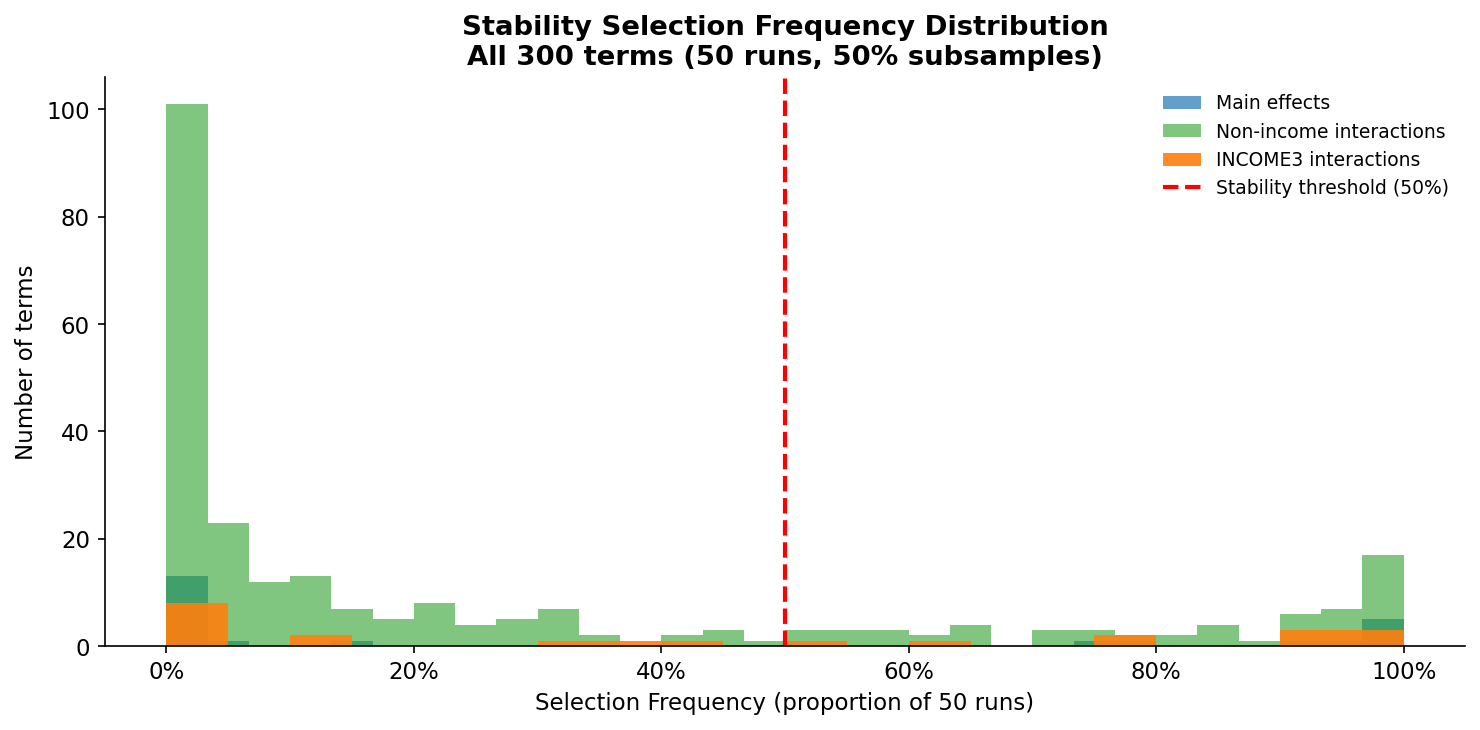

Saved fig14_stability_freq_distribution.png


In [24]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot distribution of selection frequencies
freqs = stability_df['selection_freq'].values
ax.hist(freqs[~stability_df['is_interaction'].values],
        bins=30, alpha=0.7, color='#1F77B4', label='Main effects')
ax.hist(freqs[stability_df['is_interaction'].values & 
              ~stability_df['is_income_int'].values],
        bins=30, alpha=0.6, color='#2CA02C', label='Non-income interactions')
ax.hist(freqs[stability_df['is_income_int'].values],
        bins=20, alpha=0.9, color='#FF7F0E', label='INCOME3 interactions')

ax.axvline(STABILITY_THRESHOLD, color='red', lw=2, ls='--',
           label=f'Stability threshold ({STABILITY_THRESHOLD*100:.0f}%)')

ax.set_xlabel('Selection Frequency (proportion of 50 runs)')
ax.set_ylabel('Number of terms')
ax.set_title('Stability Selection Frequency Distribution\n'
             f'All {len(stability_df)} terms ({N_STABILITY_RUNS} runs, '
             f'{SUBSAMPLE_FRAC*100:.0f}% subsamples)',
             fontweight='bold')
ax.legend(frameon=False, fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig14_stability_freq_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig14_stability_freq_distribution.png')

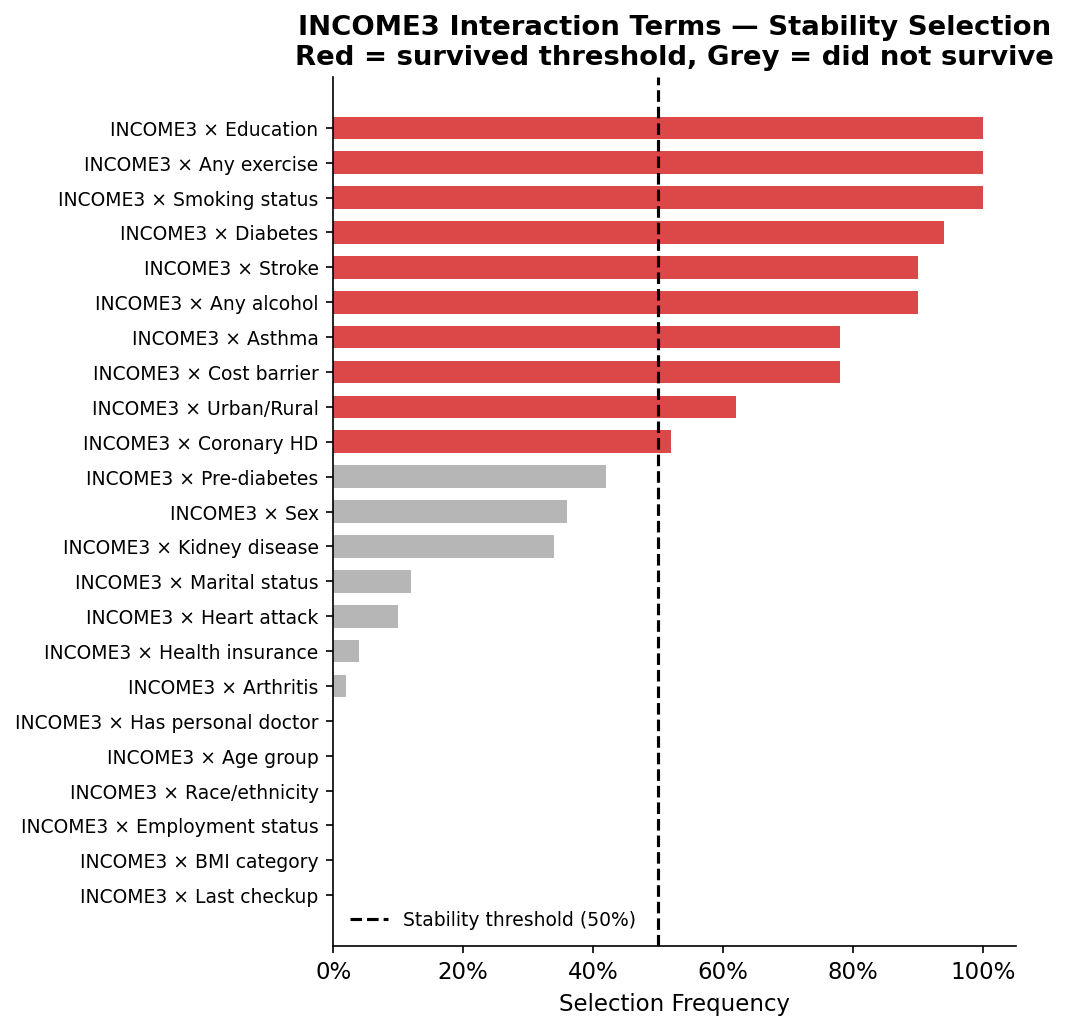

Saved fig15_income_interaction_stability.png


In [25]:
# Bar chart of selection frequency for all 23 INCOME3 × X terms,
# sorted by frequency, threshold line shown.

income_int_all = stability_df[stability_df['is_income_int']].copy()
income_int_all['partner_var'] = income_int_all['term'].str.replace(
    'INCOME3_x_', '').str.replace('_x_INCOME3', '')
income_int_all['partner_label'] = income_int_all['partner_var'].map(
    lambda x: VAR_LABELS.get(x, x))
income_int_all = income_int_all.sort_values('selection_freq', ascending=True)

fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#D62728' if f > STABILITY_THRESHOLD else '#AAAAAA'
          for f in income_int_all['selection_freq']]

ax.barh(range(len(income_int_all)),
        income_int_all['selection_freq'],
        color=colors, alpha=0.85, height=0.65)
ax.axvline(STABILITY_THRESHOLD, color='black', lw=1.5, ls='--',
           label=f'Stability threshold ({STABILITY_THRESHOLD*100:.0f}%)')

ax.set_yticks(range(len(income_int_all)))
ax.set_yticklabels(
    [f'INCOME3 × {v}' for v in income_int_all['partner_label']],
    fontsize=9)
ax.set_xlabel('Selection Frequency')
ax.set_title('INCOME3 Interaction Terms — Stability Selection\n'
             'Red = survived threshold, Grey = did not survive',
             fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig15_income_interaction_stability.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig15_income_interaction_stability.png')

In [26]:
if len(INCOME_INT_COLS) == 0:
    print('=== NULL RESULT ===')
    print('No INCOME3 interaction terms survived stability selection.')
    print('Income operates additively in COPD — the non-additive structure')
    print('hypothesised in H3 is not supported under L1 regularisation.')
    print()
    print('This is a publishable null result. Frame as:')
    print('  "Unlike in prior diabetes work, LASSO interaction screening')
    print('   under stability selection found no income interaction terms')
    print('   that survived regularisation, suggesting income operates')
    print('   additively in COPD prediction."')
    print()
    print('Proceed to notebook 08 (fairness audit).')
else:
    print(f'Building interaction-augmented model with '
          f'{len(INCOME_INT_COLS)} surviving income term(s):')
    for c in INCOME_INT_COLS:
        print(f'  {c}')

Building interaction-augmented model with 10 surviving income term(s):
  INCOME3_x_EDUCA
  INCOME3_x_EXERANY2
  INCOME3_x__SMOKER3
  INCOME3_x_DIABETES
  INCOME3_x_CVDSTRK3
  INCOME3_x_DRNKANY6
  INCOME3_x_ASTHMA3
  INCOME3_x_MEDCOST1
  INCOME3_x__URBSTAT
  INCOME3_x_CVDCRHD4


In [ ]:
# Only runs if INCOME_INT_COLS is non-empty

if len(INCOME_INT_COLS) > 0:

    def add_income_interactions(df, income_int_cols, feature_pairs):
        """Add surviving income interaction columns to a dataframe."""
        df = df.copy()
        pair_dict = {f'{a}_x_{b}': (a, b) for a, b in feature_pairs}
        for col in income_int_cols:
            a, b = pair_dict[col]
            df[col] = df[a] * df[b]
        return df

    df22_int = add_income_interactions(df22, INCOME_INT_COLS, feature_pairs)
    df23_int = add_income_interactions(df23, INCOME_INT_COLS, feature_pairs)

    INT_FEATURES = ALL_FEATURES + INCOME_INT_COLS

    X_train_int = df22_int[INT_FEATURES].copy()
    y_train_int = df22_int[OUTCOME].copy()

    print(f'Interaction-augmented training matrix: {X_train_int.shape}')
    print(f'  Original features    : {len(ALL_FEATURES)}')
    print(f'  Added interactions   : {len(INCOME_INT_COLS)}')
    print(f'  Total features       : {len(INT_FEATURES)}')

Interaction-augmented training matrix: (442913, 34)
  Original features    : 24
  Added interactions   : 10
  Total features       : 34


In [ ]:
if len(INCOME_INT_COLS) > 0:

    def youden_threshold(y_true, y_prob):
        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        return thresholds[np.argmax(tpr - fpr)]

    def run_cv_simple(pipeline, X, y, n_splits=5):
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True,
                             random_state=RANDOM_SEED)
        aucs, fold_y_true, fold_y_prob = [], [], []
        for tr_idx, val_idx in cv.split(X, y):
            pipeline.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            y_prob = pipeline.predict_proba(X.iloc[val_idx])[:, 1]
            aucs.append(roc_auc_score(y.iloc[val_idx], y_prob))
            fold_y_true.extend(y.iloc[val_idx].tolist())
            fold_y_prob.extend(y_prob.tolist())
        return np.array(aucs), np.array(fold_y_true), np.array(fold_y_prob)

    # Preprocessors for interaction-augmented matrix
    # Interaction terms go in ordinal imputer (continuous products)
    ord_int  = ORDINAL_FEATURES + INCOME_INT_COLS
    bin_int  = BINARY_FEATURES
    scale_pos_weight = (y_train_int == 0).sum() / y_train_int.sum()

    tree_pre_int = ColumnTransformer(transformers=[
        ('ord', SimpleImputer(strategy='median'),        ord_int),
        ('bin', SimpleImputer(strategy='most_frequent'), bin_int),
    ], remainder='drop')

    lr_pre_int = ColumnTransformer(transformers=[
        ('ord', Pipeline([
            ('imp',   SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
        ]), ord_int),
        ('bin', SimpleImputer(strategy='most_frequent'), bin_int),
    ], remainder='drop')

    INT_MODELS = {
        'Logistic Regression': Pipeline([
            ('pre', lr_pre_int),
            ('clf', LogisticRegression(
                class_weight='balanced', max_iter=1000,
                solver='saga', random_state=RANDOM_SEED, n_jobs=-1,
            )),
        ]),
        'Random Forest': Pipeline([
            ('pre', tree_pre_int),
            ('clf', RandomForestClassifier(
                n_estimators=100, class_weight='balanced',
                max_features='sqrt', min_samples_leaf=50,
                random_state=RANDOM_SEED, n_jobs=-1,
            )),
        ]),
        'XGBoost': Pipeline([
            ('pre', tree_pre_int),
            ('clf', xgb.XGBClassifier(
                n_estimators=200, max_depth=6, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                tree_method='hist', eval_metric='auc',
                random_state=RANDOM_SEED, n_jobs=-1, verbosity=0,
            )),
        ]),
    }

    CV_INT    = {}
    CURVES_INT = {}

    print('=== 5-Fold CV — INTERACTION-AUGMENTED MODEL ===\n')
    for name, pipeline in INT_MODELS.items():
        t0 = time.time()
        aucs, y_true_p, y_prob_p = run_cv_simple(
            pipeline, X_train_int, y_train_int)
        CV_INT[name]    = aucs
        CURVES_INT[name] = (y_true_p, y_prob_p)
        print(f'  {name:<22}  AUC={aucs.mean():.4f}±{aucs.std():.4f}  '
              f'({time.time()-t0:.1f}s)')

=== 5-Fold CV — INTERACTION-AUGMENTED MODEL ===

  Logistic Regression     AUC=0.8476±0.0016  (10.3s)
  Random Forest           AUC=0.8556±0.0020  (19.2s)
  XGBoost                 AUC=0.8575±0.0019  (7.6s)


In [ ]:
if len(INCOME_INT_COLS) > 0:

    baseline_aucs = pd.read_csv(TABLE_DIR / 'baseline_cv_summary.csv')
    baseline_auc_dict = dict(zip(baseline_aucs['Model'],
                                  baseline_aucs['auc_mean']))

    print('=== BASELINE vs INTERACTION-AUGMENTED AUC ===\n')
    print(f'{"Model":<22}  {"Baseline":>10}  {"+ Interactions":>14}  '
          f'{"ΔAUC":>8}')
    print('-' * 60)

    comparison_rows = []
    for name in INT_MODELS:
        base_auc = baseline_auc_dict[name]
        int_auc  = CV_INT[name].mean()
        delta    = int_auc - base_auc
        direction = '↑' if delta > 0 else '↓'
        print(f'{name:<22}  {base_auc:>10.4f}  {int_auc:>14.4f}  '
              f'{delta:>+8.4f}  {direction}')
        comparison_rows.append({
            'Model'        : name,
            'Baseline AUC' : base_auc,
            'Int AUC'      : int_auc,
            'Delta AUC'    : delta,
        })

    int_comparison_df = pd.DataFrame(comparison_rows)
    int_comparison_df.to_csv(TABLE_DIR / 'interaction_results.csv', index=False)

    print()
    print('Interpretation:')
    print('  ΔAUC > 0 on ≥2 models → income interaction terms improve prediction')
    print('  This supports H3: income operates through interaction-dependent pathways')
    print()
    print('Saved interaction_results.csv')

=== BASELINE vs INTERACTION-AUGMENTED AUC ===

Model                     Baseline  + Interactions      ΔAUC
------------------------------------------------------------
Logistic Regression         0.8472          0.8476   +0.0004  ↑
Random Forest               0.8558          0.8556   -0.0002  ↓
XGBoost                     0.8575          0.8575   +0.0001  ↑

Interpretation:
  ΔAUC > 0 on ≥2 models → income interaction terms improve prediction
  This supports H3: income operates through interaction-dependent pathways

Saved interaction_results.csv


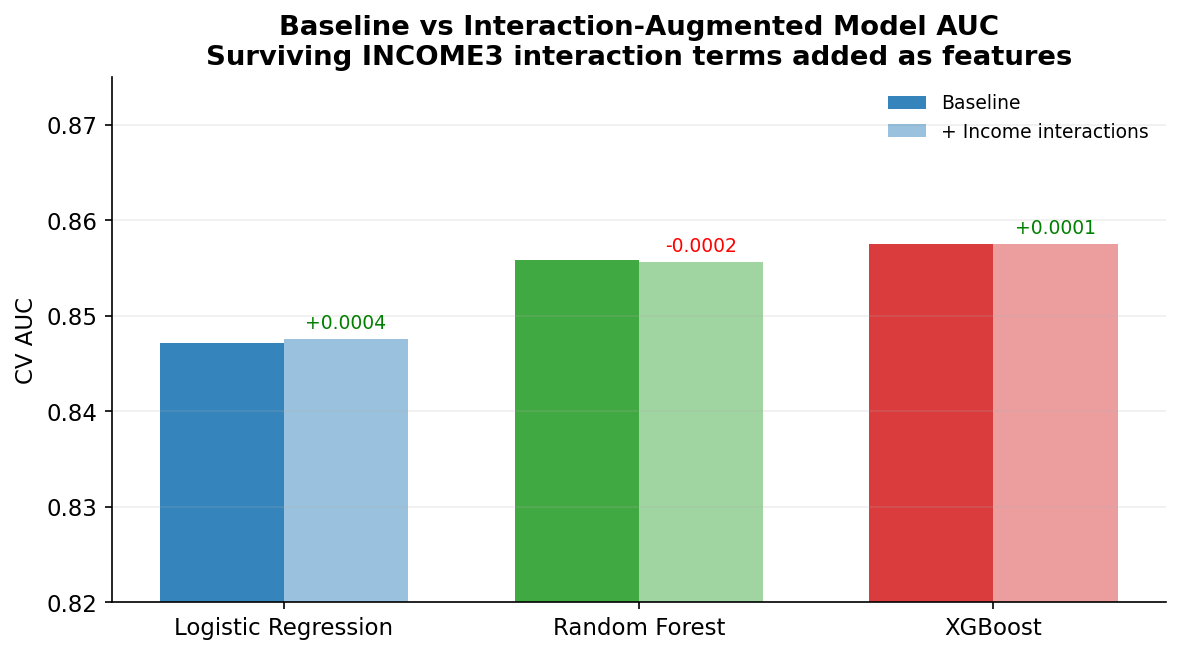

Saved fig16_interaction_auc_comparison.png


In [ ]:
if len(INCOME_INT_COLS) > 0:

    models_to_plot = list(INT_MODELS.keys())
    x = np.arange(len(models_to_plot))
    w = 0.35

    COLORS = {
        'Logistic Regression': '#1F77B4',
        'Random Forest'      : '#2CA02C',
        'XGBoost'            : '#D62728',
    }

    fig, ax = plt.subplots(figsize=(8, 4.5))

    for i, name in enumerate(models_to_plot):
        base = baseline_auc_dict[name]
        inte = CV_INT[name].mean()
        delta = inte - base

        ax.bar(i - w/2, base, w,
               color=COLORS[name], alpha=0.9, label='Baseline' if i == 0 else '')
        ax.bar(i + w/2, inte, w,
               color=COLORS[name], alpha=0.45,
               label='+ Income interactions' if i == 0 else '')
        ax.annotate(f'{delta:+.4f}',
                    xy=(i + w/2, inte),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=9,
                    color='green' if delta > 0 else 'red')

    ax.set_xticks(x)
    ax.set_xticklabels(models_to_plot)
    ax.set_ylabel('CV AUC')
    ax.set_ylim(0.82, 0.875)
    ax.set_title('Baseline vs Interaction-Augmented Model AUC\n'
                 'Surviving INCOME3 interaction terms added as features',
                 fontweight='bold')
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis='y', alpha=0.2)
    ax.axhline(0.80, color='green', ls='--', lw=1, alpha=0.5)

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig16_interaction_auc_comparison.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved fig16_interaction_auc_comparison.png')

In [ ]:
if len(INCOME_INT_COLS) > 0:

    # Fit final XGBoost on full 2022 with interactions for importance
    final_xgb_int = Pipeline([
        ('pre', ColumnTransformer(transformers=[
            ('ord', SimpleImputer(strategy='median'),        ord_int),
            ('bin', SimpleImputer(strategy='most_frequent'), bin_int),
        ], remainder='drop')),
        ('clf', xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            tree_method='hist', eval_metric='auc',
            random_state=RANDOM_SEED, n_jobs=-1, verbosity=0,
        )),
    ])

    final_xgb_int.fit(X_train_int, y_train_int)

    feature_names_int = ord_int + bin_int
    imp_int = pd.DataFrame({
        'feature'    : feature_names_int,
        'importance' : final_xgb_int.named_steps['clf'].feature_importances_,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    income_rank_int  = list(imp_int['feature']).index('INCOME3') + 1
    income_rank_base = pd.read_csv(
        TABLE_DIR / 'feature_importance_xgboost.csv'
    )
    income_rank_base_val = list(
        income_rank_base['feature']).index('INCOME3') + 1

    print('=== INCOME RANK: XGBoost ===\n')
    print(f'  Baseline model        : #{income_rank_base_val} of 24')
    print(f'  Interaction model     : #{income_rank_int} of {len(imp_int)}')
    print()
    print('Top 10 features in interaction model:')
    print(imp_int.head(10)[['feature', 'importance']].to_string(index=False))

    imp_int.to_csv(TABLE_DIR / 'feature_importance_interaction_xgboost.csv',
                   index=False)

=== INCOME RANK: XGBoost ===

  Baseline model        : #11 of 24
  Interaction model     : #25 of 34

Top 10 features in interaction model:
          feature  importance
          ASTHMA3    0.224228
         _SMOKER3    0.189629
         HAVARTH3    0.111839
          EMPLOY1    0.063538
         EXERANY2    0.051051
INCOME3_x_ASTHMA3    0.044463
         CVDCRHD4    0.042776
         CVDSTRK3    0.023947
         MEDCOST1    0.021719
         _AGEG5YR    0.019438


In [ ]:
print('=== NOTEBOOK 05 SUMMARY ===\n')
print(f'LASSO interaction screen on {len(ALL_FEATURES)}-feature matrix')
print(f'  Total pairs evaluated     : {len(feature_pairs)}')
print(f'  Stability runs            : {N_STABILITY_RUNS} × '
      f'{SUBSAMPLE_FRAC*100:.0f}% subsamples')
print(f'  Survival threshold        : >{STABILITY_THRESHOLD*100:.0f}% selection frequency')
print(f'  Reference: Meinshausen & Bühlmann (2010) J R Stat Soc B')
print()

surviving_ints = stability_df[
    stability_df['survives'] & stability_df['is_interaction']]
print(f'Surviving interaction terms : {len(surviving_ints)}')
print(f'Surviving INCOME3 terms     : '
      f'{(stability_df["survives"] & stability_df["is_income_int"]).sum()}')
print()

if len(INCOME_INT_COLS) > 0:
    print('H3 result: INCOME3 interaction terms survived regularisation ✓')
    print(f'  Surviving terms: {INCOME_INT_COLS}')
    print()
    for name in INT_MODELS:
        base = baseline_auc_dict[name]
        inte = CV_INT[name].mean()
        print(f'  {name:<22} ΔAUC = {inte-base:+.4f}')
else:
    print('H3 result: No INCOME3 interaction terms survived — null result')
    print('  Income operates additively in COPD prediction')

print()
print('Saved:')
print('  lasso_stability_scores.csv')
print('  lasso_income_interactions.csv')
if len(INCOME_INT_COLS) > 0:
    print('  interaction_results.csv')
    print('  feature_importance_interaction_xgboost.csv')
print()

=== NOTEBOOK 06 SUMMARY ===

LASSO interaction screen on 24-feature matrix
  Total pairs evaluated     : 276
  Stability runs            : 50 × 50% subsamples
  Survival threshold        : >50% selection frequency
  Reference: Meinshausen & Bühlmann (2010) J R Stat Soc B

Surviving interaction terms : 68
Surviving INCOME3 terms     : 10

H3 result: INCOME3 interaction terms survived regularisation ✓
  Surviving terms: ['INCOME3_x_EDUCA', 'INCOME3_x_EXERANY2', 'INCOME3_x__SMOKER3', 'INCOME3_x_DIABETES', 'INCOME3_x_CVDSTRK3', 'INCOME3_x_DRNKANY6', 'INCOME3_x_ASTHMA3', 'INCOME3_x_MEDCOST1', 'INCOME3_x__URBSTAT', 'INCOME3_x_CVDCRHD4']

  Logistic Regression    ΔAUC = +0.0004
  Random Forest          ΔAUC = -0.0002
  XGBoost                ΔAUC = +0.0001

Saved:
  lasso_stability_scores.csv
  lasso_income_interactions.csv
  interaction_results.csv
  feature_importance_interaction_xgboost.csv

